# 02 - GCVI Peak Detection

In [2]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

from src.config import load_config
from src.utils import setup_logging, ensure_dir
from src.peak_detection import detect_peaks, peak_qc_report, get_smoothed_and_fitted_curves

logger = setup_logging()
config = load_config()
output_dir = config['data']['output_dir']
ensure_dir('../figures')

print("Configuration loaded")
print(f"Peak detection window: {config['peak_detection']['fit_start_date']} to {config['peak_detection']['fit_end_date']}")
print(f"Valid peak months: {config['peak_detection']['valid_peak_start_month']} to {config['peak_detection']['valid_peak_end_month']}")

Configuration loaded
Peak detection window: 2025-02-01 to 2025-06-30
Valid peak months: 4 to 5


## 1. Load Raw Spectral Data

In [3]:
spectral_df = pd.read_parquet(f'{output_dir}/spectral_raw.parquet')
spectral_df['date'] = pd.to_datetime(spectral_df['date'])

print(f"Spectral data: {spectral_df.shape}")
print(f"Fields: {spectral_df['field_key'].nunique()}")
print(f"Date range: {spectral_df['date'].min()} to {spectral_df['date'].max()}")

Spectral data: (27600, 44)
Fields: 240
Date range: 2024-07-03 00:00:00 to 2025-06-28 00:00:00


## 2. Run Peak Detection Pipeline

In [4]:
peak_df, params_df = detect_peaks(spectral_df, config)

print(f"\nPeak detection results: {len(peak_df)} fields")
print(f"Double logistic params: {len(params_df)} fields")
peak_df.head(10)

03:06:13 | INFO    | Peak detection: 10560 rows in fitting window (2025-02-01 to 2025-06-30)
03:06:16 | INFO    | SG smoothing: 240/240 fields processed (resample=3d, SG(7,2), daily_interp=True)
03:06:32 | INFO    | Peak detection complete: 240/240 fields — 240 double logistic, 0 fallback, 0 skipped in smoothing
03:06:32 | INFO    | Peak QC: 12/240 (5.0%) fields flagged as anomalous
03:06:32 | INFO    |   - peak_outside_season: 12 fields
03:06:32 | INFO    |   - poor_fit: 6 fields



Peak detection results: 240 fields
Double logistic params: 240 fields


,field_key,peak_date,peak_doy,peak_gcvi,fit_method,peak_anomalous,anomaly_reason,peak_month,fit_r2,amplitude
0,1,2025-04-22,112.990991,6.633918,double_logistic,False,None,4,0.964369,8.272116
1,10,2025-04-25,115.153153,7.547166,double_logistic,False,None,4,0.859404,8.901815
2,11,2025-04-12,102.324324,6.692821,double_logistic,False,None,4,0.777694,11.343686
3,12_,2025-04-22,112.702703,8.047356,double_logistic,False,None,4,0.861612,9.174676
4,14,2025-04-20,110.252252,9.294034,double_logistic,False,None,4,0.970612,26.578985
5,16,2025-04-23,113.279279,4.049924,double_logistic,False,None,4,0.980418,9.330846
6,17,2025-04-17,107.801802,6.002015,double_logistic,False,None,4,0.955071,16.477963
7,18,2025-04-17,107.657658,8.972311,double_logistic,False,None,4,0.952887,27.398836
8,2,2025-04-26,116.594595,6.981147,double_logistic,False,None,4,0.963950,17.973743
9,3,2025-04-25,115.153153,6.999193,double_logistic,False,None,4,0.942754,19.642998


## 3. QC Report

In [5]:
qc_report = peak_qc_report(peak_df, config)

print("=" * 60)
print("PEAK DETECTION QC REPORT")
print("=" * 60)
print(f"Total fields: {qc_report['total_fields']}")
print(f"Valid fields: {qc_report['valid_fields']}")
print(f"Anomalous fields: {qc_report['anomalous_fields']} ({qc_report['pct_anomalous']:.1f}%)")
print(f"\nPeak month distribution:")
for month, count in sorted(qc_report['peak_month_distribution'].items()):
    print(f"  Month {month}: {count} fields")
print(f"\nFit method distribution:")
for method, count in qc_report['fit_method_distribution'].items():
    print(f"  {method}: {count}")
print(f"\nPeak DOY stats: mean={qc_report['peak_doy_stats']['mean']:.1f}, "
      f"std={qc_report['peak_doy_stats']['std']:.1f}")

PEAK DETECTION QC REPORT
Total fields: 240
Valid fields: 228
Anomalous fields: 12 (5.0%)

Peak month distribution:
  Month 3: 3 fields
  Month 4: 181 fields
  Month 5: 47 fields
  Month 6: 9 fields

Fit method distribution:
  double_logistic: 240

Peak DOY stats: mean=117.2, std=14.7


## 4. Visualizations

03:06:33 | INFO    | SG smoothing: 1/1 fields processed (resample=3d, SG(7,2), daily_interp=True)
03:06:33 | INFO    | SG smoothing: 1/1 fields processed (resample=3d, SG(7,2), daily_interp=True)
03:06:33 | INFO    | SG smoothing: 1/1 fields processed (resample=3d, SG(7,2), daily_interp=True)
03:06:33 | INFO    | SG smoothing: 1/1 fields processed (resample=3d, SG(7,2), daily_interp=True)
03:06:33 | INFO    | SG smoothing: 1/1 fields processed (resample=3d, SG(7,2), daily_interp=True)
03:06:33 | INFO    | SG smoothing: 1/1 fields processed (resample=3d, SG(7,2), daily_interp=True)
03:06:33 | INFO    | SG smoothing: 1/1 fields processed (resample=3d, SG(7,2), daily_interp=True)
03:06:33 | INFO    | SG smoothing: 1/1 fields processed (resample=3d, SG(7,2), daily_interp=True)
03:06:33 | INFO    | SG smoothing: 1/1 fields processed (resample=3d, SG(7,2), daily_interp=True)
03:06:34 | INFO    | SG smoothing: 1/1 fields processed (resample=3d, SG(7,2), daily_interp=True)
03:06:34 | INFO    |

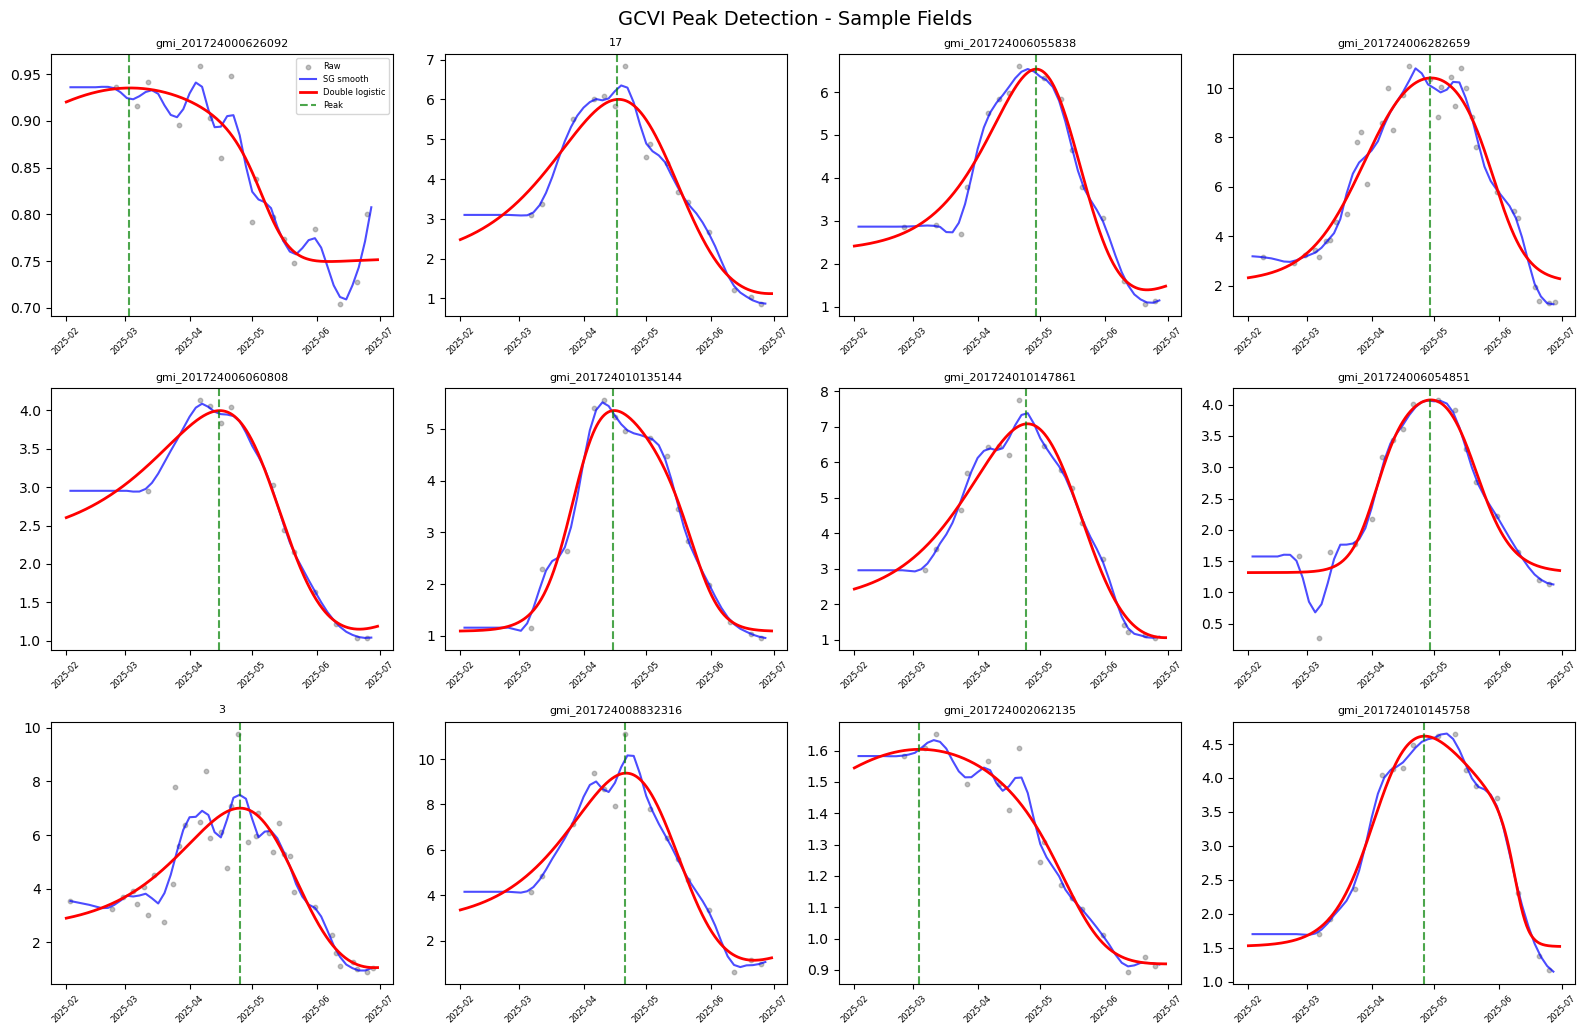

In [6]:
# Plot a grid of sample fields
sample_fields = peak_df.sample(min(12, len(peak_df)), random_state=42)['field_key'].values
n_cols = 4
n_rows = int(np.ceil(len(sample_fields) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 and n_cols == 1 else axes.flatten()

for i, fk in enumerate(sample_fields):
    ax = axes[i]
    curves = get_smoothed_and_fitted_curves(spectral_df, peak_df, params_df, config, fk)
    
    # Raw data
    if 'raw_dates' in curves:
        ax.scatter(curves['raw_dates'], curves['raw_gcvi'], s=10, alpha=0.5, label='Raw', color='gray')
    
    # Smoothed
    if 'smooth_dates' in curves:
        ax.plot(curves['smooth_dates'], curves['smooth_gcvi'], 'b-', alpha=0.7, label='SG smooth')
    
    # Fitted curve (convert DOY to dates for plotting)
    if 'fitted_doy' in curves:
        year = 2025
        fitted_dates = pd.Timestamp(f'{year}-01-01') + pd.to_timedelta(curves['fitted_doy'] - 1, unit='D')
        ax.plot(fitted_dates, curves['fitted_gcvi'], 'r-', linewidth=2, label='Double logistic')
    
    # Peak marker
    if 'peak_date' in curves:
        ax.axvline(curves['peak_date'], color='green', linestyle='--', alpha=0.7, label='Peak')
    
    ax.set_title(fk[:20], fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=6)
    if i == 0:
        ax.legend(fontsize=6)

# Hide empty axes
for j in range(len(sample_fields), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('GCVI Peak Detection - Sample Fields', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/02_gcvi_peak_detection.png', dpi=150, bbox_inches='tight')
plt.show()

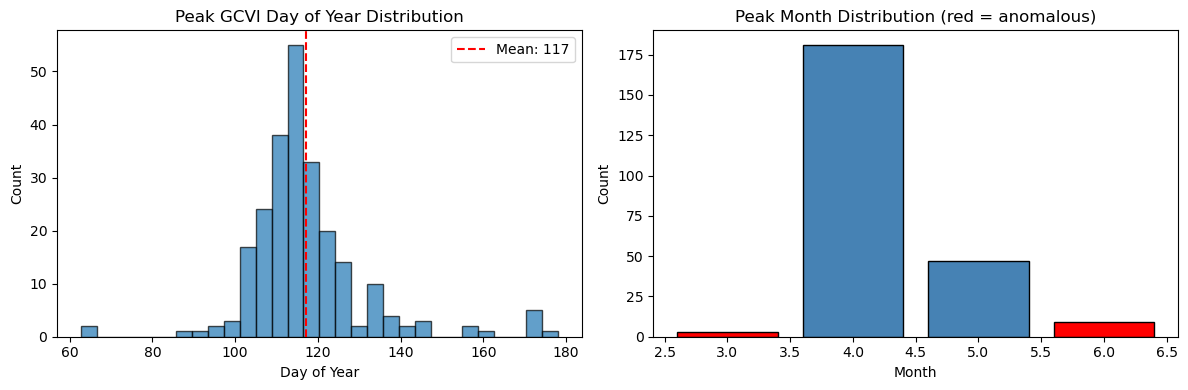

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Peak DOY histogram
axes[0].hist(peak_df['peak_doy'], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(peak_df['peak_doy'].mean(), color='red', linestyle='--', label=f"Mean: {peak_df['peak_doy'].mean():.0f}")
axes[0].set_xlabel('Day of Year')
axes[0].set_ylabel('Count')
axes[0].set_title('Peak GCVI Day of Year Distribution')
axes[0].legend()

# Peak month bar plot
month_counts = peak_df['peak_month'].value_counts().sort_index()
colors = ['red' if m < config['peak_detection']['valid_peak_start_month'] or 
          m > config['peak_detection']['valid_peak_end_month'] else 'steelblue' 
          for m in month_counts.index]
axes[1].bar(month_counts.index, month_counts.values, color=colors, edgecolor='black')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Count')
axes[1].set_title('Peak Month Distribution (red = anomalous)')

plt.tight_layout()
plt.savefig('../figures/02_peak_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 QC Dashboard

03:06:48 | INFO    | Saved QC dashboard to ../figures/peak_qc_dashboard.png


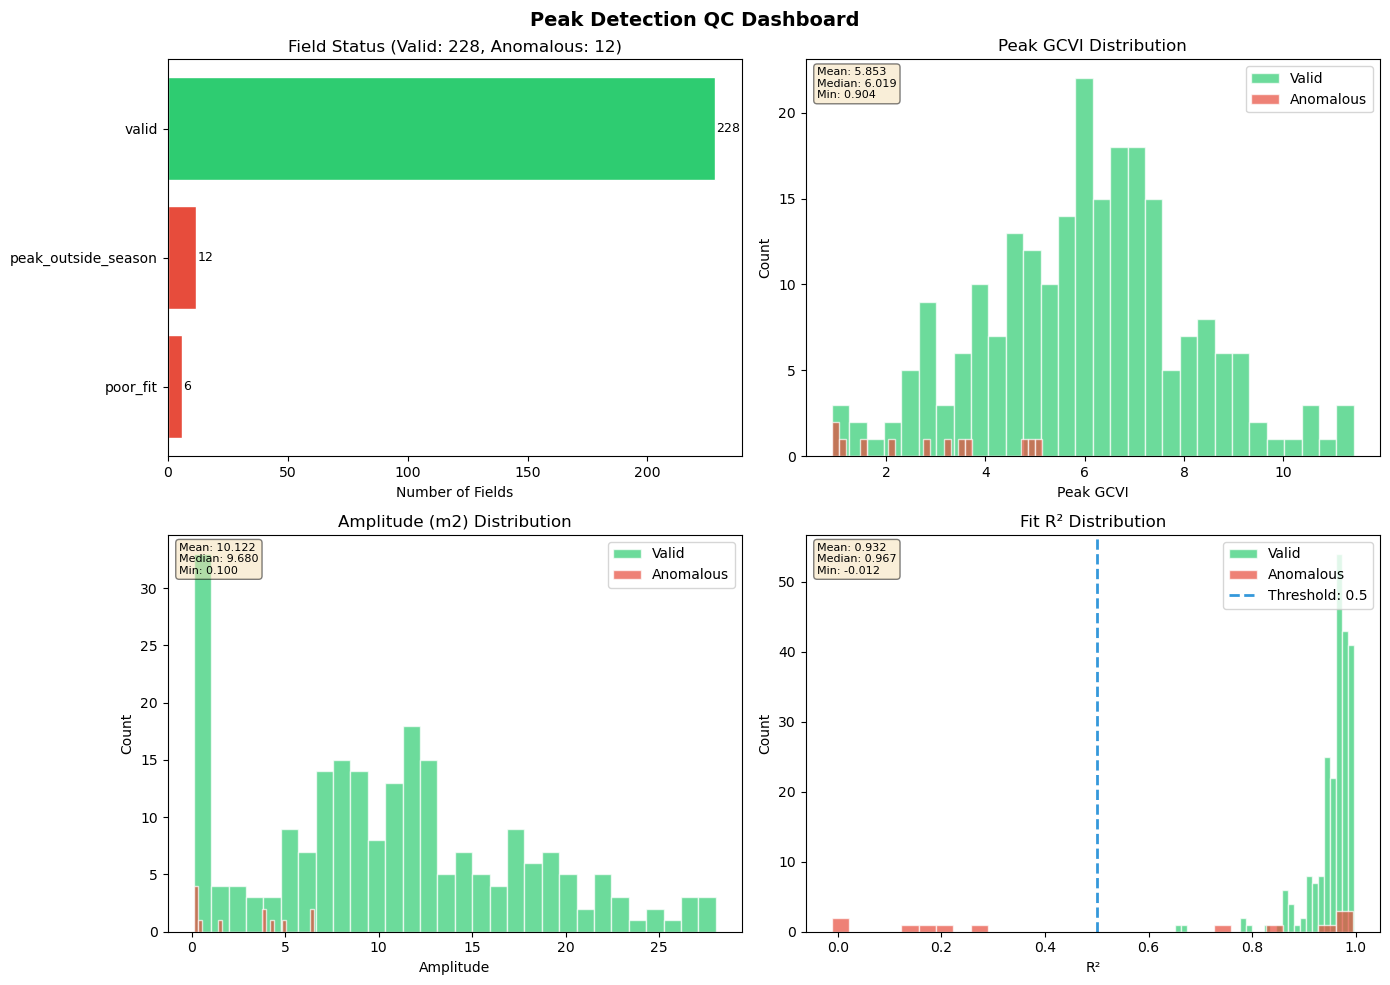

03:06:50 | INFO    | Saved QC scatter plot to ../figures/peak_qc_scatter.png


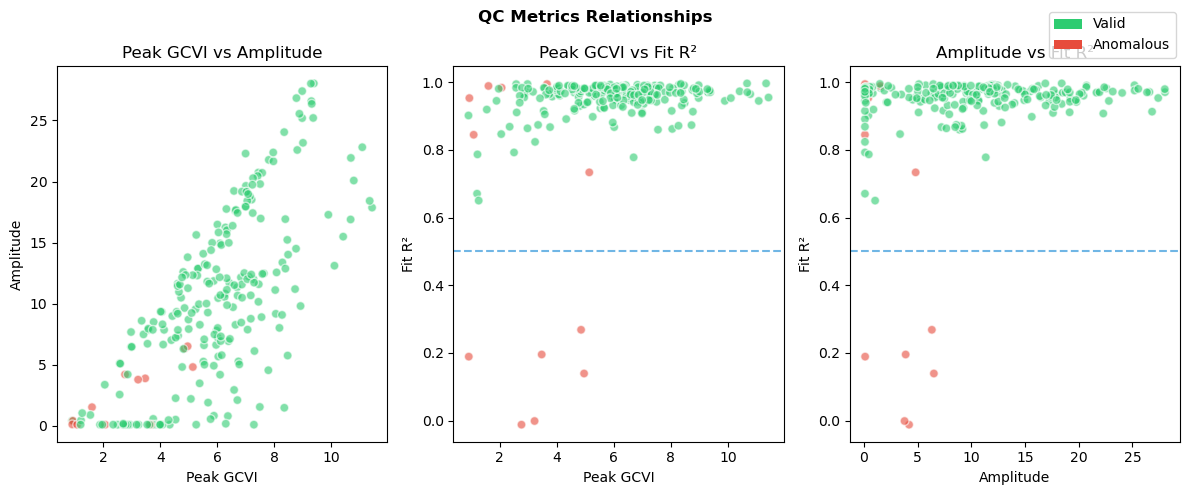

In [8]:
from src.peak_detection import plot_peak_qc_dashboard, plot_qc_scatter

# QC Dashboard: 4-panel overview of anomaly flags and distributions
fig1 = plot_peak_qc_dashboard(peak_df, config, save_path='../figures/peak_qc_dashboard.png')
plt.show()

# QC Scatter plots: relationships between amplitude, fit R², and peak GCVI
fig2 = plot_qc_scatter(peak_df, config, save_path='../figures/peak_qc_scatter.png')
plt.show()

### 4.3 Field Diagnostics

In [9]:
import plotly.express as px
import plotly.graph_objects as go

# Load static features for protein, yield, and location data
static_df = pd.read_parquet(f'{output_dir}/static_features.parquet')
diag_df = peak_df.merge(
    static_df[['field_key', 'protein_pct', 'yield_bu_ac', 'centroid_lat', 'centroid_lon']],
    on='field_key', how='left'
)

valid_start = config['peak_detection']['valid_peak_start_month']
valid_end = config['peak_detection']['valid_peak_end_month']
hover_cols = ['field_key', 'peak_date', 'peak_doy', 'peak_gcvi', 'fit_r2',
              'amplitude', 'protein_pct', 'yield_bu_ac', 'peak_anomalous']

# 1. Yield vs Peak DOY (color = peak GCVI)
fig1 = px.scatter(diag_df, x='peak_doy', y='yield_bu_ac', color='peak_gcvi',
                  color_continuous_scale='viridis', hover_data=hover_cols,
                  title='Yield vs Peak DOY (color = Peak GCVI)',
                  labels={'peak_doy': 'Peak DOY', 'yield_bu_ac': 'Yield (bu/ac)', 'peak_gcvi': 'Peak GCVI'})
fig1.add_vline(x=91, line_dash='dash', line_color='gray', opacity=0.5, annotation_text='Apr 1')
fig1.add_vline(x=152, line_dash='dot', line_color='gray', opacity=0.5, annotation_text='Jun 1')
fig1.update_traces(marker=dict(size=8, line=dict(width=0.5, color='black')))
fig1.update_layout(height=450, width=700)
fig1.show()

# 2. Protein vs Peak DOY (color = peak GCVI)
fig2 = px.scatter(diag_df, x='peak_doy', y='protein_pct', color='peak_gcvi',
                  color_continuous_scale='viridis', hover_data=hover_cols,
                  title='Protein vs Peak DOY (color = Peak GCVI)',
                  labels={'peak_doy': 'Peak DOY', 'protein_pct': 'Protein (%)', 'peak_gcvi': 'Peak GCVI'})
fig2.add_vline(x=91, line_dash='dash', line_color='gray', opacity=0.5, annotation_text='Apr 1')
fig2.add_vline(x=152, line_dash='dot', line_color='gray', opacity=0.5, annotation_text='Jun 1')
fig2.update_traces(marker=dict(size=8, line=dict(width=0.5, color='black')))
fig2.update_layout(height=450, width=700)
fig2.show()

# 3. Spatial map with basemap (color = anomalous flag)
diag_df['status'] = diag_df['peak_anomalous'].map({True: 'Anomalous', False: 'Valid'})
fig3 = px.scatter_mapbox(diag_df, lat='centroid_lat', lon='centroid_lon', color='status',
                         color_discrete_map={'Valid': 'steelblue', 'Anomalous': 'red'},
                         size_max=12, hover_data=hover_cols,
                         title=f'Spatial Distribution (anomalous = peak outside months {valid_start}-{valid_end})',
                         mapbox_style='open-street-map',
                         zoom=6, center={'lat': diag_df['centroid_lat'].mean(),
                                         'lon': diag_df['centroid_lon'].mean()})
fig3.update_traces(marker=dict(size=10))
fig3.update_layout(height=550, width=750)
fig3.show()

# Summary stats
n_anom = diag_df['peak_anomalous'].sum()
normal = diag_df[~diag_df['peak_anomalous']]
anomalous = diag_df[diag_df['peak_anomalous']]
print(f"Anomalous peak fields: {n_anom}/{len(diag_df)} ({100*n_anom/len(diag_df):.1f}%)")
print(f"Valid peak DOY range: {normal['peak_doy'].min():.0f} - {normal['peak_doy'].max():.0f}")
print(f"Anomalous peak DOY range: {anomalous['peak_doy'].min():.0f} - {anomalous['peak_doy'].max():.0f}" if len(anomalous) > 0 else "No anomalous fields")

C:\Users\Vlasis\AppData\Local\Temp\ipykernel_8212\722861725.py:40: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



Anomalous peak fields: 12/240 (5.0%)
Valid peak DOY range: 92 - 146
Anomalous peak DOY range: 63 - 178


## 5. Save Results

In [ ]:
peak_df.to_csv(f'{output_dir}/peak_days.csv', index=False)
if not params_df.empty:
    params_df.to_csv(f'{output_dir}/double_logistic_params.csv', index=False)

# Save QC report
with open(f'{output_dir}/peak_qc_report.json', 'w') as f:
    json.dump(qc_report, f, indent=2, default=str)

print(f"Saved peak_days.csv: {len(peak_df)} fields")
print(f"Saved double_logistic_params.csv: {len(params_df)} fields")
print(f"Saved peak_qc_report.json")

## 6. Late-Peak Fields (DOY > 155)

In [11]:
# Identify the late-peak, low-R² fields (the circled cluster in the scatter plot)
late_low = peak_df[(peak_df['peak_doy'] > 155)].sort_values('fit_r2')
print(f"Fields with Peak DOY > 155: {len(late_low)}")
print(f"R² range: {late_low['fit_r2'].min():.3f} – {late_low['fit_r2'].max():.3f}")
print()
late_low[['field_key', 'peak_date', 'peak_doy', 'peak_gcvi', 'fit_r2', 'amplitude', 'peak_anomalous']].reset_index(drop=True)

Fields with Peak DOY > 155: 9
R² range: -0.012 – 0.994



,field_key,peak_date,peak_doy,peak_gcvi,fit_r2,amplitude,peak_anomalous
0,gmi_201724001014041,2025-06-22,173.531532,2.761573,-0.011591,4.208179,True
1,gmi_201724003152621,2025-06-22,173.531532,3.220239,-0.000832,3.786179,True
2,gmi_201724005924403,2025-06-22,173.531532,4.956515,0.139445,6.515737,True
3,gmi_201724001014256,2025-06-27,178.000000,0.913702,0.189297,0.118673,True
4,gmi_201724000625108,2025-06-22,173.531532,3.470028,0.195590,3.888523,True
5,gmi_201724003152483,2025-06-22,173.531532,4.851438,0.268535,6.327577,True
6,gmi_201724004262807,2025-06-08,159.837838,1.085359,0.844391,0.100000,True
7,gmi_201724006055584,2025-06-04,155.801802,2.064434,0.983419,0.100000,True
8,gmi_201724005262551,2025-06-05,156.810811,3.656682,0.994061,0.100000,True


03:06:58 | INFO    | SG smoothing: 1/1 fields processed (resample=3d, SG(7,2), daily_interp=True)
03:06:58 | INFO    | SG smoothing: 1/1 fields processed (resample=3d, SG(7,2), daily_interp=True)
03:06:58 | INFO    | SG smoothing: 1/1 fields processed (resample=3d, SG(7,2), daily_interp=True)
03:06:58 | INFO    | SG smoothing: 1/1 fields processed (resample=3d, SG(7,2), daily_interp=True)
03:06:58 | INFO    | SG smoothing: 1/1 fields processed (resample=3d, SG(7,2), daily_interp=True)
03:06:58 | INFO    | SG smoothing: 1/1 fields processed (resample=3d, SG(7,2), daily_interp=True)
03:06:58 | INFO    | SG smoothing: 1/1 fields processed (resample=3d, SG(7,2), daily_interp=True)
03:06:59 | INFO    | SG smoothing: 1/1 fields processed (resample=3d, SG(7,2), daily_interp=True)
03:06:59 | INFO    | SG smoothing: 1/1 fields processed (resample=3d, SG(7,2), daily_interp=True)


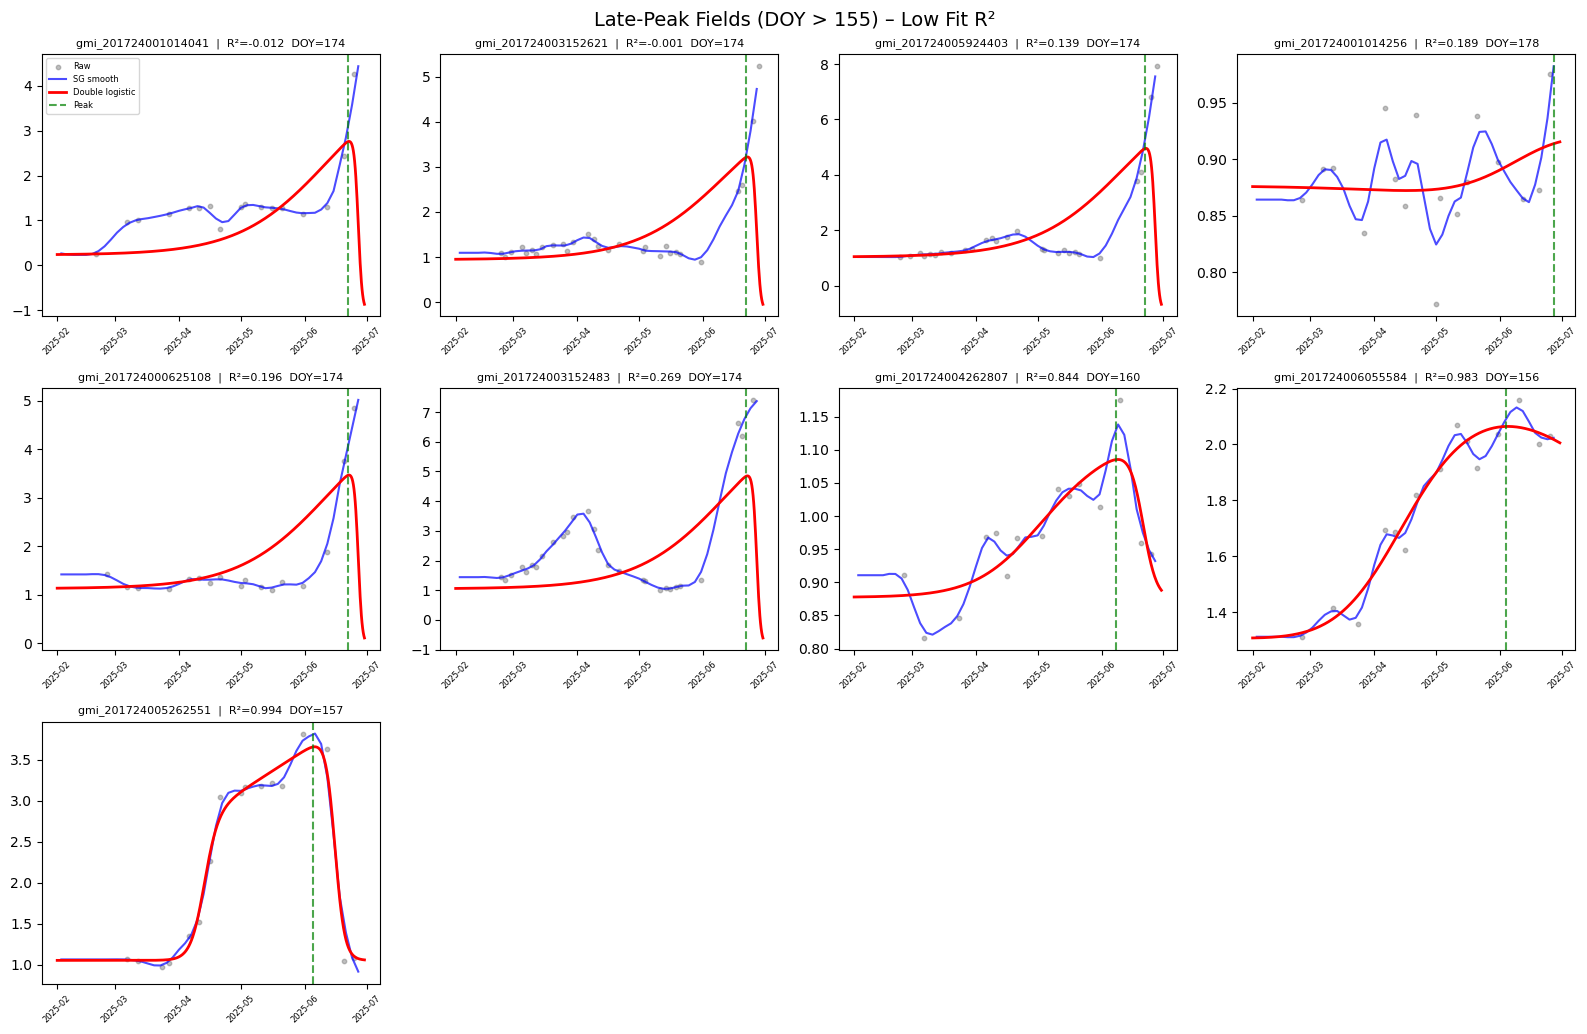

In [12]:
# Plot GCVI curves for the late-peak, low-R² fields
late_fields = late_low['field_key'].values
n_cols = 4
n_rows = int(np.ceil(len(late_fields) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))
axes = axes.flatten() if n_rows > 1 else (np.array([axes]) if n_cols == 1 else axes.flatten())

for i, fk in enumerate(late_fields):
    ax = axes[i]
    curves = get_smoothed_and_fitted_curves(spectral_df, peak_df, params_df, config, fk)
    row = peak_df[peak_df['field_key'] == fk].iloc[0]

    # Raw data
    if 'raw_dates' in curves:
        ax.scatter(curves['raw_dates'], curves['raw_gcvi'], s=10, alpha=0.5, label='Raw', color='gray')

    # Smoothed
    if 'smooth_dates' in curves:
        ax.plot(curves['smooth_dates'], curves['smooth_gcvi'], 'b-', alpha=0.7, label='SG smooth')

    # Fitted curve
    if 'fitted_doy' in curves:
        fitted_dates = pd.Timestamp('2025-01-01') + pd.to_timedelta(curves['fitted_doy'] - 1, unit='D')
        ax.plot(fitted_dates, curves['fitted_gcvi'], 'r-', linewidth=2, label='Double logistic')

    # Peak marker
    if 'peak_date' in curves:
        ax.axvline(curves['peak_date'], color='green', linestyle='--', alpha=0.7, label='Peak')

    ax.set_title(f"{fk}  |  R²={row['fit_r2']:.3f}  DOY={row['peak_doy']:.0f}", fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=6)
    if i == 0:
        ax.legend(fontsize=6)

for j in range(len(late_fields), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Late-Peak Fields (DOY > 155) – Low Fit R²', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/02_late_peak_low_r2_curves.png', dpi=150, bbox_inches='tight')
plt.show()